In [ ]:
import numpy as np

# Data points

X = np.array([1, 2, 3, 4, 5])

Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

# Stack the design matrix with a column of ones (for the intercept)

A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares

m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

print(f"Slope: {m}, Intercept: {c}")

Slope: 0.9500000000000001, Intercept: 0.5900000000000001


In [ ]:
Y_random = np.copy(Y)
np.random.shuffle(Y_random)

In [ ]:
A = np.vstack([X, np.ones(len(X))]).T
m_rand, c_rand = np.linalg.lstsq(A, Y_random, rcond=None)[0]

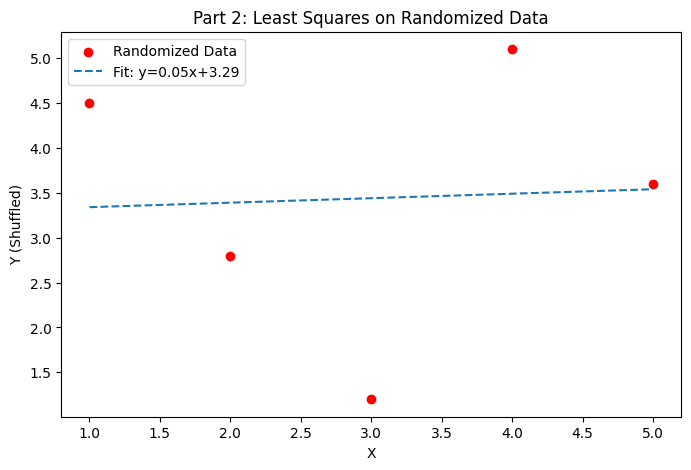

Randomized Fit -> Slope: 0.05, Intercept: 3.29


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(X, Y_random, color='red', label='Randomized Data')
plt.plot(X, m_rand*X + c_rand, label=f'Fit: y={m_rand:.2f}x+{c_rand:.2f}', linestyle='--')
plt.title("Part 2: Least Squares on Randomized Data")
plt.xlabel("X")
plt.ylabel("Y (Shuffled)")
plt.legend()
plt.show()

print(f"Randomized Fit -> Slope: {m_rand:.2f}, Intercept: {c_rand:.2f}")

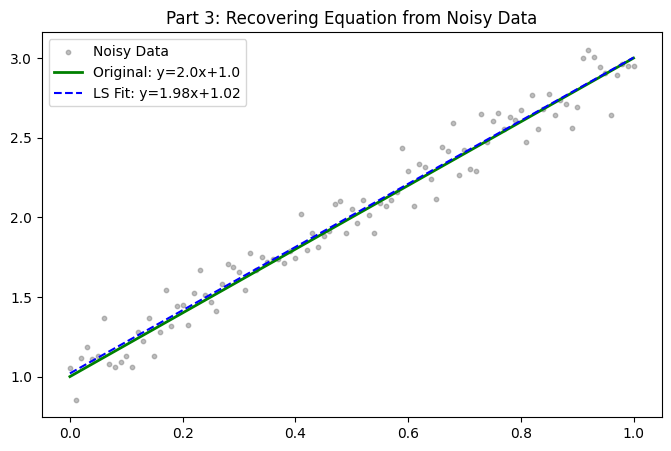

Original: m=2.0, c=1.0
Recovered: m=1.9831, c=1.0202


In [7]:
# 1. Define X from 0 to 1 in steps of 0.01
x_part3 = np.arange(0, 1.01, 0.01)

# 2. Define your own linear equation (e.g., y = 2x + 1)
true_m = 2.0
true_c = 1.0
y_pure = true_m * x_part3 + true_c

# 3. Add a random perturbation (noise)
noise = np.random.normal(0, 0.1, len(x_part3)) # Mean 0, Std Dev 0.1
y_noisy = y_pure + noise

# 4. Compute Least Squares for the noisy data
A_part3 = np.vstack([x_part3, np.ones(len(x_part3))]).T
m_calc, c_calc = np.linalg.lstsq(A_part3, y_noisy, rcond=None)[0]

# Plotting Part 3
plt.figure(figsize=(8, 5))
plt.scatter(x_part3, y_noisy, s=10, color='gray', alpha=0.5, label='Noisy Data')
plt.plot(x_part3, y_pure, color='green', label=f'Original: y={true_m}x+{true_c}', linewidth=2)
plt.plot(x_part3, m_calc*x_part3 + c_calc, color='blue', label=f'LS Fit: y={m_calc:.2f}x+{c_calc:.2f}', linestyle='--')
plt.title("Part 3: Recovering Equation from Noisy Data")
plt.legend()
plt.show()

print(f"Original: m={true_m}, c={true_c}")
print(f"Recovered: m={m_calc:.4f}, c={c_calc:.4f}")